# 00. Качество данных



In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.db import get_engine, query, save_mart
from src import viz

viz.setup()
engine = get_engine()

## 1. Сводка по заказам

In [2]:
checks = query(engine, "quality_checks.sql")
checks.T

,0
rows_total,88716
orders_unique,85490
first_created,2017-01-05 11:56:06
last_created,2018-07-15 23:59:54
first_paid,2017-01-06 12:43:41
last_paid,2018-07-14 10:28:00
rows_not_paid,692
rows_paid_before_created,107
rows_bad_price,0
rows_bad_quantity,0


In [3]:
q = """
select order_id, count(*) as rows_per_order
from sandbox.order_details
group by order_id
order by rows_per_order desc
limit 10
"""
pd.read_sql_query(q, engine)

,order_id,rows_per_order
0,7d8f5bfd-5aff-6482-2037-4a2df62e84d5,7
1,ad850e69-fce9-a512-ada8-4086651a2e7d,7
2,5efc0b7f-e9df-7f0c-5674-04abaa4d25fc,6
3,2455cbeb-73fd-04b1-70ca-2504662f95ce,6
4,e43f8886-3d1c-c9cf-f18d-753d439d42e8,6
5,1c11d0f4-353b-31ac-3417-fbfa5f0f2a8a,6
6,200f4d88-3fcc-7013-55e4-6b8c6035743f,6
7,5a3b1c29-a497-56e7-5f1e-f513383c0c12,6
8,3990f966-93d3-21ac-142f-ff312bf3706a,6
9,99330d45-c3ba-6f45-ad57-45f6de036c5f,6


## 2. Границы периода и обрыв данных

In [4]:
created = query(engine, "sales_created_daily.sql")
paid = query(engine, "sales_paid_daily.sql")

created = viz.add_time_parts(created, "dt")
paid = viz.add_time_parts(paid, "dt")

print("created:", created.dt.min().date(), "-", created.dt.max().date())
print("paid:   ", paid.dt.min().date(), "-", paid.dt.max().date())

created: 2017-01-05 - 2018-07-15
paid:    2017-01-06 - 2018-07-14


In [5]:
days_per_month = (
    created.groupby("month")
    .agg(days_with_data=("dt", "nunique"), gmv=("gmv_created", "sum"))
    .reset_index()
)
days_per_month["days_in_month"] = days_per_month.month.dt.days_in_month
days_per_month["coverage"] = (
    days_per_month.days_with_data / days_per_month.days_in_month * 100
).round(1)
days_per_month.tail(5)

,month,days_with_data,gmv,days_in_month,coverage
14,2018-03-01,31,951426.19,31,100.0
15,2018-04-01,30,981490.70,30,100.0
16,2018-05-01,31,978876.09,31,100.0
17,2018-06-01,30,859495.57,30,100.0
18,2018-07-01,15,333396.68,31,48.4


In [6]:
full_months = days_per_month.loc[days_per_month.coverage >= 95, "month"]
LAST_FULL_MONTH = full_months.max()
print("последний полный месяц:", LAST_FULL_MONTH.date())

последний полный месяц: 2018-06-01


Июль 2018 года заполнен не полными данными, дальше мы его не будем рассматривать и сравнивать

## 3. Пропуски в дате выкупа

In [7]:
q = '''
select
    count(*)                                              as orders_total,
    sum(case when date_paid is null then 1 else 0 end)    as orders_not_paid
from sandbox.orders
'''
paid_gap = pd.read_sql_query(q, engine)
paid_gap["share_not_paid"] = (
    paid_gap.orders_not_paid / paid_gap.orders_total * 100
).round(1)
paid_gap

,orders_total,orders_not_paid,share_not_paid
0,85490,669,0.8


Метрики роста считаем по `date_created`, маржу по `date_paid`


## 4. Сходимость GMV created и GMV paid

In [8]:
gmv_created_total = created.gmv_created.sum()
gmv_paid_total = paid.gmv_paid.sum()

print(f"GMV created: {gmv_created_total:,.0f}")
print(f"GMV paid:    {gmv_paid_total:,.0f}")
print(f"выкуп:       {gmv_paid_total / gmv_created_total * 100:.1f}%")

GMV created: 11,748,728
GMV paid:    11,629,865
выкуп:       99.0%


## 5. Аномалии в значениях

In [9]:
q = '''
select
    min(price) as price_min, max(price) as price_max,
    min(quantity) as qty_min, max(quantity) as qty_max,
    min(commission) as comm_min, max(commission) as comm_max
from sandbox.order_details
'''
pd.read_sql_query(q, engine).T

,0
price_min,0.85
price_max,6735.00
qty_min,1.00
qty_max,20.00
comm_min,0.13
comm_max,0.38


## 6. Распределение среднего чека

count    85490.0
mean       137.4
std        208.3
min          0.8
50%         87.0
90%        270.0
95%        399.9
99%        990.0
max      13440.0
Name: order_sum, dtype: float64


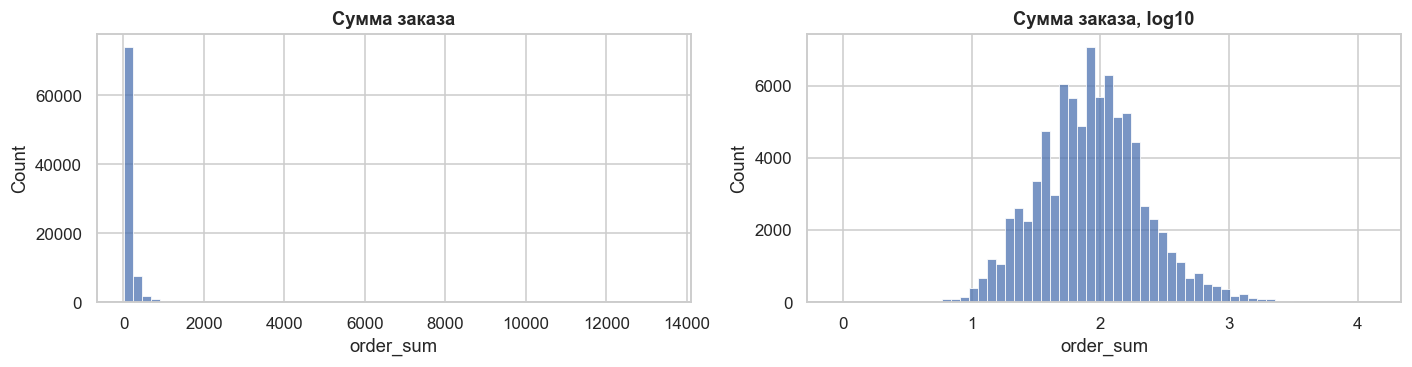

In [10]:
q = '''
select order_id, sum(price * quantity) as order_sum
from sandbox.order_details
group by order_id
'''
orders_sum = pd.read_sql_query(q, engine)

print(orders_sum.order_sum.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(1))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
sns.histplot(orders_sum.order_sum, bins=60, ax=ax[0])
ax[0].set_title("Сумма заказа")
sns.histplot(np.log10(orders_sum.order_sum.clip(lower=0.01)), bins=60, ax=ax[1])
ax[1].set_title("Сумма заказа, log10")
plt.tight_layout()
plt.show()

In [11]:
p99 = orders_sum.order_sum.quantile(0.99)
heavy = orders_sum.loc[orders_sum.order_sum > p99]
print(f"заказов выше 99 перцентиля: {len(heavy)}")
print(f"их доля в обороте: {heavy.order_sum.sum() / orders_sum.order_sum.sum() * 100:.1f}%")

заказов выше 99 перцентиля: 846
их доля в обороте: 11.3%


## Итоги по качеству данных

Заполнить своими словами, по пунктам:

1. с Января 2017 по Июль 2018
2. 0.8% , 99.2% заказов выкуплены
3. price от 0.85 до 6735, quantity от 1 до 20, commission от 0.13 до 0.38. Аномалия: 107 строк, где дата выкупа раньше даты создания
4. Распределение суммы заказа сильно скошено вправо: медиана 87, среднее 137, то есть среднее выше медианы в 1.6 раза. Верхний 1% заказов (846 штук, от 990) даёт 11.3% оборота при максимуме 13 440
5. Июль 2018 неполный. Невыкуплено 0.8% заказов, прибыль считать по date_paid, метрики роста по date_created